In [1]:
import pandas as pd
import numpy as np
import csv
from pathlib import Path
from collections import defaultdict
pd.set_option('display.max_columns', 50)

RAW_PATH = Path("APS-000258_20251002_000000.csv")
ENCODING = "cp1252"
OUT_DIR = Path("APS-000258_20251002_000000")
OUT_DIR.mkdir(exist_ok=True)

#### 1 Đọc file

In [9]:
with open(RAW_PATH, "r", encoding=ENCODING) as f:
    reader = csv.reader(f, delimiter=",")
    rows = list(reader)

for r in rows[:10]:
    print(r[:5], "...")

['Log Type', 'System', 'Time Stamp', 'Column Header...', ''] ...
['APS Ctrl Trig', 'APS', 'TimeStamp', 'Milliseconds/ms', 'AirAir1State'] ...
['APS Energy', 'APS', 'TimeStamp', 'W_in_APU1/kWh', 'W_out_APU1/kWh'] ...
['APS Stat 10s', 'APS', 'TimeStamp', 'Irr/(W/m^2)', ''] ...
['APS Stat 60s', 'APS', 'TimeStamp', 'Tamb/°C', 'Tpan/°C'] ...
['APS Stat Trig', 'APS', 'TimeStamp', 'Milliseconds/ms', 'OpState'] ...
['APS Switching Cycles', 'APS', 'TimeStamp', 'APU1_AC', 'APU1_DC'] ...
['APU Ctrl Trig', 'APU', 'TimeStamp', 'Milliseconds/ms', 'PSetL1/kW'] ...
['APU Stat 10s', 'APU', 'TimeStamp', 'VL1N/V', 'VL2N/V'] ...
['APU Stat 60s', 'APU', 'TimeStamp', 'TInd/°C', 'TL1/°C'] ...


#### 2 Trích xuất schema cho từng log type 

In [25]:
SCHEMA_ROWS = rows[1:12]
DATA_ROWS = rows[12:]
schema = {}
for r in SCHEMA_ROWS:
    log_type = r[0]
    col_names = [c for c in r[3:] if c.strip() != ""] # both empty and space-only columns are ignored
    schema[log_type] = col_names
schema_overview = pd.DataFrame(
    [(k, len(v)) for k, v in schema.items()],
    columns=["log_type", "so cot du lieu"]
).sort_values("so cot du lieu", ascending=False)
schema_overview

,log_type,so cot du lieu
10,APU Energy,24
9,APU Stat Trig,20
0,APS Ctrl Trig,20
7,APU Stat 10s,19
4,APS Stat Trig,18
6,APU Ctrl Trig,15
1,APS Energy,14
5,APS Switching Cycles,12
3,APS Stat 60s,9
8,APU Stat 60s,6


#### 3 Tách dữ liệu theo log type

In [26]:
buckets = defaultdict(list)
for r in DATA_ROWS:
    buckets[r[0]].append(r)
raw_tables = {}
for log_type, cols in schema.items():
    recs = buckets.get(log_type, [])
    if not recs:
        print(f"Warning: no records found for log_type {log_type}")
        continue
    n = len(cols)
    data = []
    for r in recs:
        vals = r[3:3+n]
        vals = vals + [""] * (n - len(vals))  # pad with empty strings if not enough values
        data.append([r[1],r[2]] + vals)
    raw_tables[log_type] = pd.DataFrame(data, columns=["System", "TimeStamp"] + cols)
for k, v in raw_tables.items():
    print(f"{k:24} -> {v.shape[0]:6,d} rows, {v.shape[1]:2d} columns")

APS Ctrl Trig            ->     63 rows, 22 columns
APS Energy               ->  1,421 rows, 16 columns
APS Stat 60s             ->  1,421 rows, 11 columns
APS Stat Trig            ->    133 rows, 20 columns
APS Switching Cycles     ->      9 rows, 14 columns
APU Ctrl Trig            ->  6,884 rows, 17 columns
APU Stat 10s             -> 36,103 rows, 21 columns
APU Stat 60s             ->  5,684 rows,  8 columns
APU Stat Trig            ->    580 rows, 22 columns
APU Energy               ->  5,684 rows, 26 columns


#### 4 Chuẩn hóa kiểu dữ liệu

In [27]:
def clean_table(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["TimeStamp"] = pd.to_datetime(df["TimeStamp"], dayfirst=True, errors="coerce")

    value_cols = [c for c in df.columns if c not in ("System", "TimeStamp", "Log Type")]
    for c in value_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Tách số hiệu unit từ "APU 1" -> 1 ; "APS" -> NaN (chỉ có 1 trạm APS)
    #df["Unit"] = df["System"].str.extract(r"(\d+)$").astype("Int64")

    # Sắp theo thời gian, đưa Unit lên gần đầu cho dễ đọc
    cols_order = ["Log Type", "System", "TimeStamp"] + value_cols
    df = df.reindex(columns=[c for c in cols_order if c in df.columns] + 
                     [c for c in df.columns if c not in cols_order])
    df = df.sort_values(["System", "TimeStamp"]).reset_index(drop=True)
    return df

clean_tables = {}
for log_type, df in raw_tables.items():
    df = df.assign(**{"Log Type": log_type})
    clean_tables[log_type] = clean_table(df)

clean_tables["APU Stat 10s"].head()

,Log Type,System,TimeStamp,VL1N/V,VL2N/V,VL3N/V,VL12/V,VL23/V,VL31/V,f/Hz,IL1/A,IL2/A,IL3/A,PL1/kW,PL2/kW,PL3/kW,QL1/kvar,QL2/kvar,QL3/kvar,Vdc/V,Idc/A,Pdc/kW
0,APU Stat 10s,APU 1,2025-10-02,376.4544,377.4921,374.4517,651.5374,649.5901,653.0925,50.23788,0.419486,0.506285,0.432055,0.0,0.0,0.0,0.0,0.0,0.0,0.186415,0.174510,0.000049
1,APU Stat 10s,APU 1,2025-10-02,375.0524,376.0415,375.2791,650.5810,648.5026,652.0964,50.21109,0.441678,0.496331,0.392818,0.0,0.0,0.0,0.0,0.0,0.0,0.231532,0.194776,0.000000
2,APU Stat 10s,APU 1,2025-10-02,375.3925,375.8795,375.7714,651.3182,650.5690,652.7217,50.19405,0.418474,0.511242,0.452410,0.0,0.0,0.0,0.0,0.0,0.0,0.267963,0.198036,0.000049
3,APU Stat 10s,APU 1,2025-10-02,374.3089,376.3658,375.4110,652.2673,649.1951,652.3290,50.19383,0.391712,0.502023,0.391270,0.0,0.0,0.0,0.0,0.0,0.0,0.227911,0.172205,0.000049
4,APU Stat 10s,APU 1,2025-10-02,374.3701,376.4231,375.4413,652.5290,649.1609,652.6641,50.20052,0.407831,0.522918,0.402317,0.0,0.0,0.0,0.0,0.0,0.0,0.233433,0.218858,0.000451


#### 5 kiểm tra chất lượng dữ liệu

In [28]:
quality_rows = []
for log_type, df in clean_tables.items():
    value_cols = [c for c in df.columns if c not in ("Log Type", "System", "Unit", "TimeStamp")]
    missing_pct = df[value_cols].isna().mean().mean() * 100 if value_cols else np.nan
    fully_empty_cols = [c for c in value_cols if df[c].isna().all()]
    quality_rows.append({
        "Log Type": log_type,
        "So dong": len(df),
        "Tu ngay": df["TimeStamp"].min(),
        "Den ngay": df["TimeStamp"].max(),
        "% thieu TB cac cot": round(missing_pct, 2),
        "So dong trung lap (toan bo cot)": int(df.duplicated().sum()),
        "So cot toan rong": len(fully_empty_cols),
        "Ten cot toan rong": ", ".join(fully_empty_cols) if fully_empty_cols else "-",
    })

quality_report = pd.DataFrame(quality_rows)
quality_report

,Log Type,So dong,Tu ngay,Den ngay,% thieu TB cac cot,So dong trung lap (toan bo cot),So cot toan rong,Ten cot toan rong
0,APS Ctrl Trig,63,2025-10-02,2025-10-02 17:37:00,0.0,0,0,-
1,APS Energy,1421,2025-10-02,2025-10-02 23:40:00,0.0,0,0,-
2,APS Stat 60s,1421,2025-10-02,2025-10-02 23:40:00,0.0,0,0,-
3,APS Stat Trig,133,2025-10-02,2025-10-02 17:41:00,0.0,0,0,-
4,APS Switching Cycles,9,2025-10-02,2025-10-02 05:33:00,0.0,0,0,-
5,APU Ctrl Trig,6884,2025-10-02,2025-10-02 17:35:00,0.0,760,0,-
6,APU Stat 10s,36103,2025-10-02,2025-10-02 23:40:00,0.0,0,0,-
7,APU Stat 60s,5684,2025-10-02,2025-10-02 23:40:00,0.0,0,0,-
8,APU Stat Trig,580,2025-10-02,2025-10-02 17:35:00,0.0,430,0,-
9,APU Energy,5684,2025-10-02,2025-10-02 23:40:00,0.0,0,0,-


In [29]:
def slugify(name: str) -> str:
    return name.lower().replace(" ", "_")

data_dict_rows = []
for log_type, df in clean_tables.items():
    fname = OUT_DIR / f"{slugify(log_type)}.csv"
    df.to_csv(fname, index=False)
    for c in df.columns:
        data_dict_rows.append({"Log Type": log_type, "Cot": c, "Kieu du lieu": str(df[c].dtype)})

pd.DataFrame(data_dict_rows).to_csv(OUT_DIR / "data_dictionary.csv", index=False)
quality_report.to_csv(OUT_DIR / "quality_report.csv", index=False)

print("Da luu cac file sau vao", OUT_DIR.resolve(), ":")
for f in sorted(OUT_DIR.iterdir()):
    print(" -", f.name)

Da luu cac file sau vao C:\PV\APS-000258_20251002_000000 :
 - aps_ctrl_trig.csv
 - aps_energy.csv
 - aps_stat_60s.csv
 - aps_stat_trig.csv
 - aps_switching_cycles.csv
 - apu_ctrl_trig.csv
 - apu_energy.csv
 - apu_stat_10s.csv
 - apu_stat_60s.csv
 - apu_stat_trig.csv
 - data_dictionary.csv
 - quality_report.csv


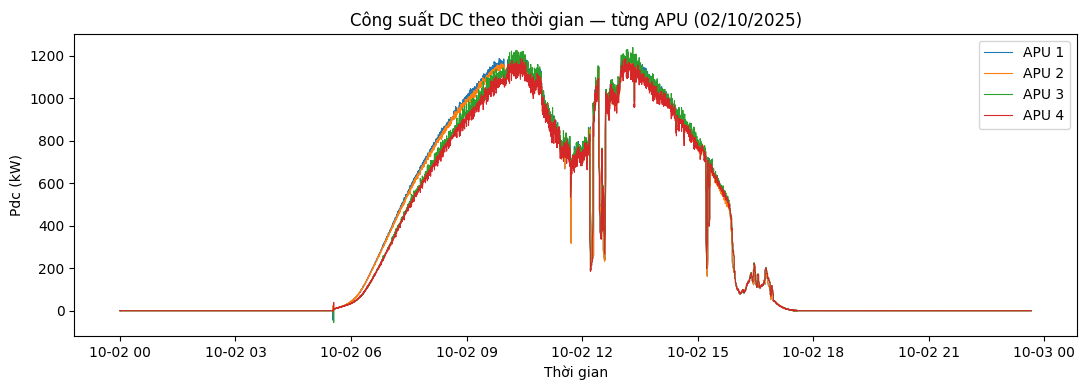

In [31]:
import matplotlib.pyplot as plt

df = clean_tables["APU Stat 10s"]
fig, ax = plt.subplots(figsize=(11, 4))
for unit, g in df.groupby("System"):
    ax.plot(g["TimeStamp"], g["Pdc/kW"], label=unit, linewidth=0.8)
ax.set_xlabel("Thời gian")
ax.set_ylabel("Pdc (kW)")
ax.set_title("Công suất DC theo thời gian — từng APU (02/10/2025)")
ax.legend()
plt.tight_layout()
plt.show()